In [28]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

# 0. Experiment selection

In [29]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

Testing experiment: da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr
Device: cuda:1


In [30]:
# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 64
- Seed: 42
- Max hits: 500


# 1. Load trained models: basic + domain discriminator

In [31]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()

# Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Domain discriminator parameters: {sum(p.numel() for p in domain_discriminator.parameters()):,}")

Loading checkpoint from: ../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr/best_da_model.pth
Models loaded successfully:
- Epoch: 45
- Best metric: 0.9471539535737066
- Base model parameters: 53,185
- Domain discriminator parameters: 2,113


# 2. Load data to test on

## 2.1 Source (MC) domain

In [32]:
# Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']

# Use validation portion of source data for testing (events model hasn't seen)
test_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
print(f"Test dataset created with {len(test_dataset)} events")
print(f"Particle distribution:")
for particle in source_config['particle_types']:
    count = sum(1 for i in range(len(test_dataset)) if test_dataset.event_ids[i].split(":")[0] == particle)
    print(f"  {particle}: {count:,} events")
    
    
# Create test dataloader
test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {test_dataloader.batch_size}")
print(f"- Number of batches: {len(test_dataloader)}")
print(f"- Total events: {len(test_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

Test dataset created with 1000000 events
Particle distribution:
  muatm_2020: 500,000 events
  nue2_2020: 250,000 events
  nuatm_2020: 250,000 events
Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]


## 2.2 Target (EXP) domain

In [33]:
# Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)

target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

In [34]:
print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


# 3. Make predctions and extract meta-info

## 3.1 Source (MC) domain

In [35]:
# Make predictions on test data
print("Making predictions...")

all_predictions = []
all_probabilities = []
all_labels = []
all_features = []
all_magic_numbers = []
all_channels_ids = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        all_features.append(feature_repr.cpu())
        all_predictions.append(predictions_batch.cpu())
        all_probabilities.append(probabilities_batch.cpu())
        all_labels.append(batch['labels'].cpu())
        all_magic_numbers.append(batch['magic_numbers'])
        all_channels_ids.append(batch['channels_ids'])

# Concatenate all results
features = torch.cat(all_features, dim=0).numpy()
predictions = torch.cat(all_predictions, dim=0).numpy().flatten()
probabilities = torch.cat(all_probabilities, dim=0).numpy().flatten()
labels = torch.cat(all_labels, dim=0).numpy().flatten()
magic_numbers = []
for values in all_magic_numbers:
    magic_numbers += values
channels_ids = []
for values in all_channels_ids:
    channels_ids += values

print(f"Predictions complete:")
print(f"- Features shape: {features.shape}")
print(f"- Predictions shape: {predictions.shape}")
print(f"- Labels shape: {labels.shape}")
print(f"- Neutrino prediction rate: {np.mean(predictions):.3f}")
print(f"- True neutrino rate: {np.mean(labels):.3f}")

Making predictions...


100%|██████████| 3907/3907 [01:03<00:00, 61.33it/s]


Predictions complete:
- Features shape: (1000000, 64)
- Predictions shape: (1000000,)
- Labels shape: (1000000,)
- Neutrino prediction rate: 0.439
- True neutrino rate: 0.500


In [36]:
signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in magic_numbers])
signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(magic_numbers, channels_ids)])

(array([ 59130., 320908., 299000., 161131.,      0.,  77796.,  45059.,
         21334.,   9810.,   5832.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

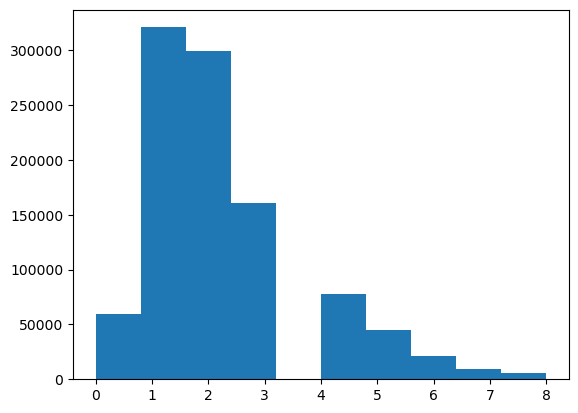

In [37]:
plt.hist(signal_string_nums)

## 3.2 Target (EXP) domain

In [38]:
# Source features (limited sample)
source_features_mu = torch.tensor(features[~labels], device=DEVICE)

# Target features
target_features = []
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        feature_repr = model.get_feature_representation(batch)
        target_features.append(feature_repr)

# Combine and test domain discrimination
target_features = torch.cat(target_features, dim=0)

all_domain_features = torch.cat([source_features_mu, target_features], dim=0)#.to(DEVICE)
domain_labels = torch.cat([
    torch.zeros(source_features_mu.shape[0]),  # 0 = source
    torch.ones(target_features.shape[0])    # 1 = target
], dim=0)

# Get domain predictions
with torch.no_grad():
    domain_logits = domain_discriminator(all_domain_features)
    domain_probs = torch.sigmoid(domain_logits).cpu().numpy().flatten()
    domain_preds = (domain_probs > 0.5).astype(float)

domain_accuracy = accuracy_score(domain_labels.numpy(), domain_preds)
domain_auc = roc_auc_score(domain_labels.numpy(), domain_probs)
print(f"Domain discrimination accuracy: {domain_accuracy:.4f}")
print(f"Domain discrimination AUC: {domain_auc:.4f}")
print(f"Note: Lower accuracy indicates better domain adaptation")
print(f"Source samples: {source_features_mu.shape[0]:,}")
print(f"Target samples: {target_features.shape[0]:,}")

100%|██████████| 1368/1368 [00:20<00:00, 66.63it/s]


Domain discrimination accuracy: 0.7032
Domain discrimination AUC: 0.7818
Note: Lower accuracy indicates better domain adaptation
Source samples: 500,000
Target samples: 349,976


# 4. Plots and analysis

## 4.1 NuMu classification

### Metrics dict

In [39]:
# Calculate comprehensive metrics
print("=== Classification Metrics ===")


for h, s in [(0, 0), (5,2), (8,2), (16,2)]:
    mask = (signal_hit_nums>=h)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]

    # Basic metrics
    accuracy = accuracy_score(labels_masked, predictions_mask)
    precision = precision_score(labels_masked, predictions_mask, average='binary')
    recall = recall_score(labels_masked, predictions_mask, average='binary')
    f1 = f1_score(labels_masked, predictions_mask, average='binary')
    auc = roc_auc_score(labels_masked, probabilities_masked)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

    # Per-class metrics
    precision_muon = precision_score(labels_masked, predictions_mask, pos_label=0)
    precision_neutrino = precision_score(labels_masked, predictions_mask, pos_label=1)
    recall_muon = recall_score(labels_masked, predictions_mask, pos_label=0)
    recall_neutrino = recall_score(labels_masked, predictions_mask, pos_label=1)

    print(f"\nPer-class metrics:")
    print(f"Muon     - Precision: {precision_muon:.4f}, Recall: {recall_muon:.4f}")
    print(f"Neutrino - Precision: {precision_neutrino:.4f}, Recall: {recall_neutrino:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Class distribution
    total_muons = np.sum(labels_masked == 0)
    total_neutrinos = np.sum(labels_masked == 1)
    print(f"\nClass distribution:")
    print(f"Total muons: {total_muons:,}")
    print(f"Total neutrinos: {total_neutrinos:,}")
    print(f"Balance: {total_neutrinos/(total_muons+total_neutrinos):.3f}")
    
    # Save results
    results_dict = {
        'experiment': EXPERIMENT_DIR.name,
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc': float(auc),
        'precision_muon': float(precision_muon),
        'precision_neutrino': float(precision_neutrino),
        'recall_muon': float(recall_muon),
        'recall_neutrino': float(recall_neutrino),
        'confusion_matrix': cm.tolist(),
        'total_muons': int(total_muons),
        'total_neutrinos': int(total_neutrinos),
        'test_events': len(predictions)
    }
    # Save to file
    results_path = f"{report_dir}/test_results_h{h}_s{s}.yaml"
    with open(results_path, 'w') as f:
        yaml.dump(results_dict, f, default_flow_style=False, indent=2, sort_keys=False)

    print(f"\nResults saved to: {results_path}")

=== Classification Metrics ===
Accuracy:  0.8676
Precision: 0.9190
Recall:    0.8063
F1 Score:  0.8590
AUC:       0.9510

Per-class metrics:
Muon     - Precision: 0.8275, Recall: 0.9290
Neutrino - Precision: 0.9190, Recall: 0.8063

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     464489  35511
    Neutrino    96841  403159

Class distribution:
Total muons: 500,000
Total neutrinos: 500,000
Balance: 0.500

Results saved to: ../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr/report_BigMCSample_EqualAtmAtsro/test_results_h0_s0.yaml
Accuracy:  0.9266
Precision: 0.9604
Recall:    0.9034
F1 Score:  0.9311
AUC:       0.9851

Per-class metrics:
Muon     - Precision: 0.8906, Recall: 0.9548
Neutrino - Precision: 0.9604, Recall: 0.9034

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     218933  10364
    Neutrino    26902  251644

Class distribution:
Total muons: 229,297
Total neutrinos: 278,

### Confusion matricies

In [40]:
treshold = 0.5
for h, s in [(0, 0), (5,2), (8,2), (16,2)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)

    print(f"\nResults for Hits>={h}, Stings>={s}")
    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Create figure
    plt.figure(figsize=(8,6))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap="Blues", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

    # Customize plot
    plt.title("Nu-EAS Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Set labels if provided
    class_labels = ['EAS', 'Nu']
    plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
    plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
    plt.tight_layout()
    numu_cm_fig = plt.gcf()
    numu_cm_fig.savefig(f"{fig_dir}/cm_h{h}_s{s}_tr{treshold:.3f}.png")
    plt.close()


Results for Hits>=0, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     464489  35511
    Neutrino    96841  403159

Results for Hits>=5, Stings>=2
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     196653   9815
    Neutrino    24673  227714

Results for Hits>=8, Stings>=2
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     108540   3810
    Neutrino     7884  138674

Results for Hits>=16, Stings>=2
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     32781    648
    Neutrino      689  49819


### ROC curves

In [41]:
_ = plt.figure(figsize=(8,8))
#plt.ylim(0.8,1.01)

roc_curves = []
for h, s,color in [(0, 0, 'red'), (5,2,'orange'), (8,2,'green'), (16,2,'lightgreen')]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
    fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
    auc = roc_auc_score(labels_masked, probabilities_masked)
    acc = accuracy_score(labels_masked, predictions_mask)
    
    geq = r"$\geq$"
    if h==0 and s==0:
        label_plot = f"No cuts\nAUC={auc:.4f}"
    elif s==0:
        label_plot = f"Hits{geq}{h}\nAUC={auc:.4f}"
    elif h==0:
        label_plot = f"Strings{geq}{s}\nAUC={auc:.4f}"
    else:
        label_plot = f"Hits{geq}{h}, Strings{geq}{s}\nAUC={auc:.4f}"
    print(label_plot)
    print(f"\tFPR at 99% TPR: {fpr[tpr>=0.99][0]:.3f}. Suppression to {1/fpr[tpr>=0.99][0]:.1f} times!")
    print(f"\tAccuracy: {acc*100:.2f}%")
    roc_plot, = plt.plot(fpr, tpr, ls='-', color=color, lw=2, label=label_plot)
    roc_curves.append(roc_plot)

# Plot roc using noise only
mask = (signal_hit_nums==0)
labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
auc = roc_auc_score(labels_masked, probabilities_masked)
noise_only_line, = plt.plot(fpr, tpr, color='grey', lw=2, label="Noise only: Hits=0")

# Plot diagonal reference line
random_line, = plt.plot(np.linspace(0,1,1000), np.linspace(0,1,1000), 'k--', lw=1, alpha=1., label='Random Classifier')
plt.hlines(0.99, 0, 1, ls='--', lw=1, color='blue', label='Nu TPR=99%')

legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Nu Recall)")
plt.title("ROC Curve")

plt.minorticks_on()
plt.grid(which='both', axis='y', alpha=1., linestyle=':')
plt.grid(which='major', axis='x', alpha=1., linestyle=':')
# Save first state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_s2.png")
#plt.show(False)

plt.title("ROC Curve (Log FPR)")
plt.xscale('log')
plt.ylim(0.1,1.)
noise_only_line.remove()
for roc_plot in roc_curves:
    roc_plot.set_marker('*')
    roc_plot.set_markersize(3.)
    roc_plot.set_linewidth(0.8)
legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)
# Save second state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_log_s2.png")
#plt.show(False)


plt.title("ROC Curve (Log FPR, closer look)")
plt.xscale('log')
plt.ylim(0.8,1.)
plt.xlim(0.001)

# Save third state
plt.tight_layout()
random_line.remove()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_close_s2.png")
#plt.show(False)
plt.close()

No cuts
AUC=0.9510
	FPR at 99% TPR: 0.455. Suppression to 2.2 times!
	Accuracy: 86.76%
Hits$\geq$5, Strings$\geq$2
AUC=0.9842
	FPR at 99% TPR: 0.207. Suppression to 4.8 times!
	Accuracy: 92.48%
Hits$\geq$8, Strings$\geq$2
AUC=0.9937
	FPR at 99% TPR: 0.120. Suppression to 8.3 times!
	Accuracy: 95.48%
Hits$\geq$16, Strings$\geq$2
AUC=0.9990
	FPR at 99% TPR: 0.031. Suppression to 32.4 times!
	Accuracy: 98.41%


## 4.2 Source-Target domain classification

### Confusion matricies

In [42]:
treshold = 0.5
for h, s in [(0, 0), (5,2), (8,2), (16,2)]:
    mask = np.concatenate(
        [
            (signal_hit_nums[~labels]>=h) & (signal_string_nums[~labels]>=s), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
    labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
    predictions_mask = (probabilities_masked>=treshold)

    print(f"\nResults for Hits>={h}, Stings>={s}")
    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                MC   Exp")
    print(f" MC     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f" Exp    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Create figure
    plt.figure(figsize=(8,6))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap="Blues", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

    # Customize plot
    plt.title("Domain Classifier Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Set labels if provided
    class_labels = ['Simulation', 'Experiment']
    plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
    plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
    plt.tight_layout()
    numu_cm_fig = plt.gcf()
    numu_cm_fig.savefig(f"{fig_dir}/DA_cm_h{h}_s{s}_tr{treshold:.3f}.png")
    plt.close()


Results for Hits>=0, Stings>=0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     344464  155536
 Exp    96773  253203

Results for Hits>=5, Stings>=2
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     167888  38580
 Exp    96773  253203

Results for Hits>=8, Stings>=2
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     97962  14388
 Exp    96773  253203

Results for Hits>=16, Stings>=2
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     30632   2797
 Exp    96773  253203



Results for Hits==0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     31356  16035
 Exp    96773  253203


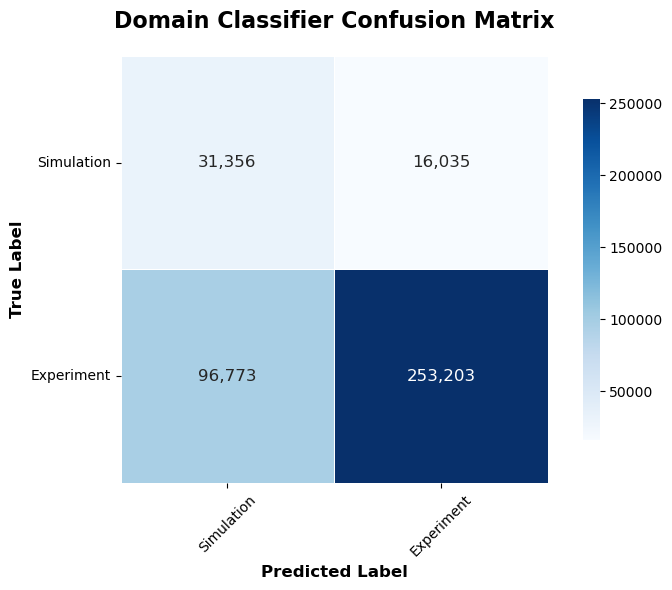

In [43]:
# Where do noise-only events go?
mask = np.concatenate(
        [
            (signal_hit_nums[~labels]==0), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
predictions_mask = (probabilities_masked>=treshold)

print(f"\nResults for Hits==0")
# Confusion matrix
cm = confusion_matrix(labels_masked, predictions_mask)
print(f"Confusion Matrix:")
print(f"                 Predicted")
print(f"                MC   Exp")
print(f" MC     {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f" Exp    {cm[1,0]:5d}  {cm[1,1]:5d}")

# Create figure
plt.figure(figsize=(8,6))

# Create heatmap
sns.heatmap(cm, annot=True, fmt=',d',
            cmap="Blues", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

# Customize plot
plt.title("Domain Classifier Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

# Set labels if provided
class_labels = ['Simulation', 'Experiment']
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
plt.tight_layout()
numu_cm_fig = plt.gcf()
numu_cm_fig.savefig(f"{fig_dir}/DA_cm_noiseonly_tr{treshold:.3f}.png")
plt.show()
plt.close()

### ROC Curves

No cuts
AUC=0.7818
	FPR at 99% TPR: 0.891. Suppression to 1.1 times!
	Accuracy: 70.32%
Hits$\geq$5, Strings$\geq$2
AUC=0.8521
	FPR at 99% TPR: 0.837. Suppression to 1.2 times!
	Accuracy: 75.68%
Hits$\geq$8, Strings$\geq$2
AUC=0.8833
	FPR at 99% TPR: 0.826. Suppression to 1.2 times!
	Accuracy: 75.96%
Hits$\geq$16, Strings$\geq$2
AUC=0.9030
	FPR at 99% TPR: 0.879. Suppression to 1.1 times!
	Accuracy: 74.03%


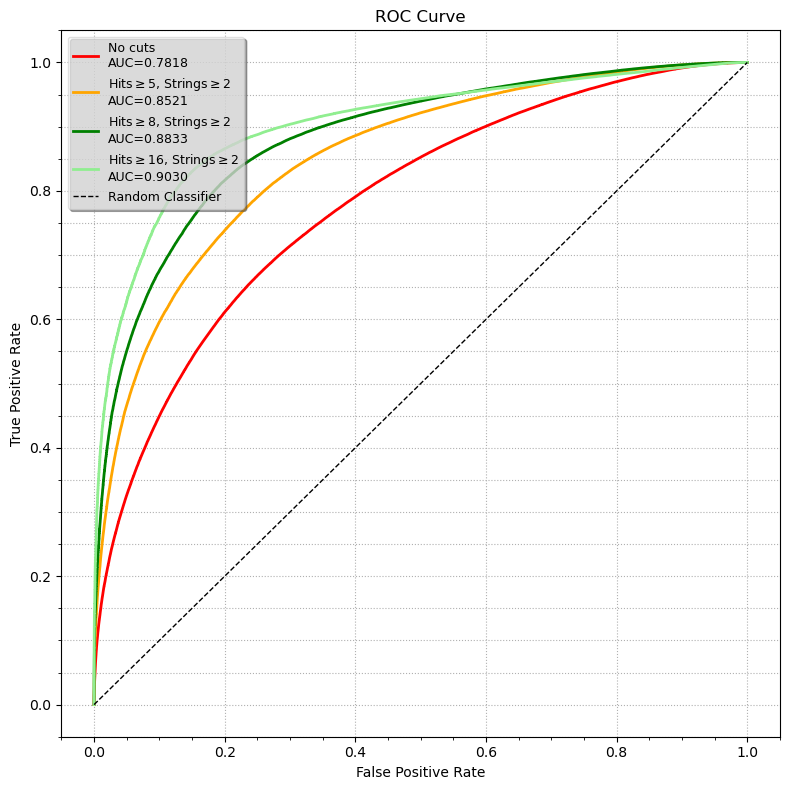

In [44]:
_ = plt.figure(figsize=(8,8))
#plt.ylim(0.8,1.01)

roc_curves = []
for h, s,color in [(0, 0, 'red'), (5,2,'orange'), (8,2,'green'), (16,2,'lightgreen')]:
    mask = np.concatenate(
        [
            (signal_hit_nums[~labels]>=h) & (signal_string_nums[~labels]>=s), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
    labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
    fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
    auc = roc_auc_score(labels_masked, probabilities_masked)
    acc = accuracy_score(labels_masked, (probabilities_masked>=0.5))
    
    geq = r"$\geq$"
    if h==0 and s==0:
        label_plot = f"No cuts\nAUC={auc:.4f}"
    elif s==0:
        label_plot = f"Hits{geq}{h}\nAUC={auc:.4f}"
    elif h==0:
        label_plot = f"Strings{geq}{s}\nAUC={auc:.4f}"
    else:
        label_plot = f"Hits{geq}{h}, Strings{geq}{s}\nAUC={auc:.4f}"
    print(label_plot)
    print(f"\tFPR at 99% TPR: {fpr[tpr>=0.99][0]:.3f}. Suppression to {1/fpr[tpr>=0.99][0]:.1f} times!")
    print(f"\tAccuracy: {acc*100:.2f}%")
    roc_plot, = plt.plot(fpr, tpr, ls='-', color=color, lw=2, label=label_plot)
    roc_curves.append(roc_plot)

# # Plot roc using noise only
# mask = np.concatenate(
#         [
#             (signal_hit_nums[~labels]==0),
#             np.ones(target_features.size(0), dtype=bool)
#         ]
#     )
# labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
# fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
# auc = roc_auc_score(labels_masked, probabilities_masked)
# noise_only_line, = plt.plot(fpr, tpr, color='grey', lw=2, label="Noise only: Hits=0")

# Plot diagonal reference line
random_line, = plt.plot(np.linspace(0,1,1000), np.linspace(0,1,1000), 'k--', lw=1, alpha=1., label='Random Classifier')

legend = plt.legend(loc="upper left", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.minorticks_on()
plt.grid(which='both', axis='y', alpha=1., linestyle=':')
plt.grid(which='major', axis='x', alpha=1., linestyle=':')
# Save first state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/discriminator_roc_curves_s2.png")
plt.show()
plt.close()

In [45]:
cm = confusion_matrix(labels_masked, (1-probabilities_masked>=0.49), normalize='true')
cm

array([[0.07969129, 0.92030871],
       [0.71292603, 0.28707397]])

## 4.3 Predictions distributions

### Classifier p-distr

In [46]:
for h, s in [(0, 0), (5,2), (8,2), (16,2)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Nu only')
    plt.hist(probabilities_masked[~labels_masked], bins=100, color='coral', density=True, log=True, histtype='step', lw=2., label='For EAS only')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.minorticks_on()
    plt.grid(which='both', ls=':', lw=0.9)

    
    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/p_distr_h{h}_s{s}.png")
    #plt.show()
    plt.close()

### MC-EXP comparison

In [47]:
# Make p preds for EXP data
print("Making predictions...")

exp_numu_predictions = []
exp_numu_probabilities = []
exp_numu_features = []

with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_numu_features.append(feature_repr.cpu())
        exp_numu_predictions.append(predictions_batch.cpu())
        exp_numu_probabilities.append(probabilities_batch.cpu())

# Concatenate all results
exp_features = torch.cat(exp_numu_features, dim=0).numpy()
exp_predictions = torch.cat(exp_numu_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_numu_probabilities, dim=0).numpy().flatten()

print(f"Predictions complete:")
print(f"- Features shape: {exp_features.shape}")
print(f"- Predictions shape: {exp_predictions.shape}")
print(f"- Neutrino prediction rate: {np.mean(exp_predictions):.3f}")

Making predictions...


100%|██████████| 1368/1368 [00:22<00:00, 60.42it/s]

Predictions complete:
- Features shape: (349976, 64)
- Predictions shape: (349976,)
- Neutrino prediction rate: 0.307


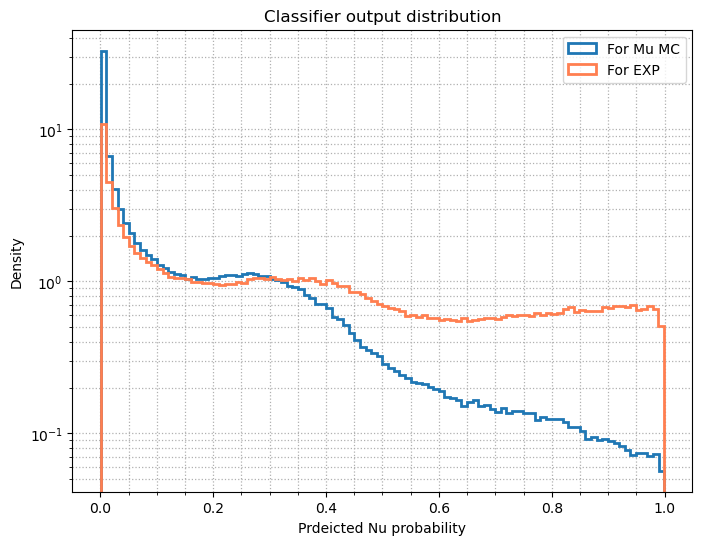

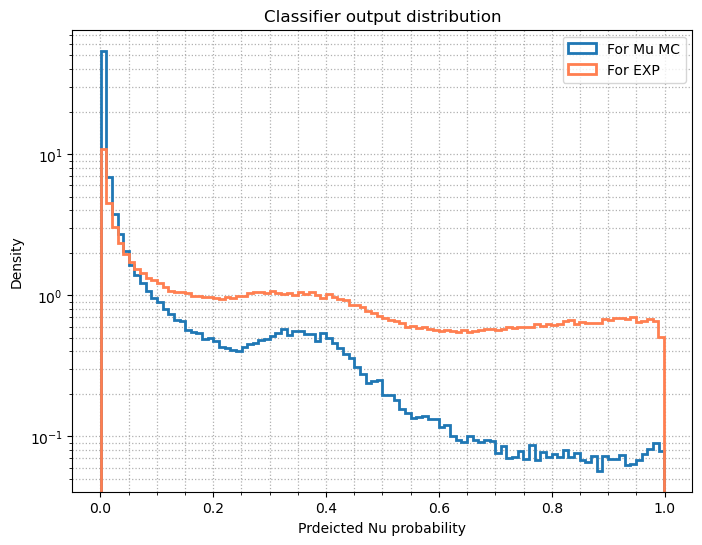

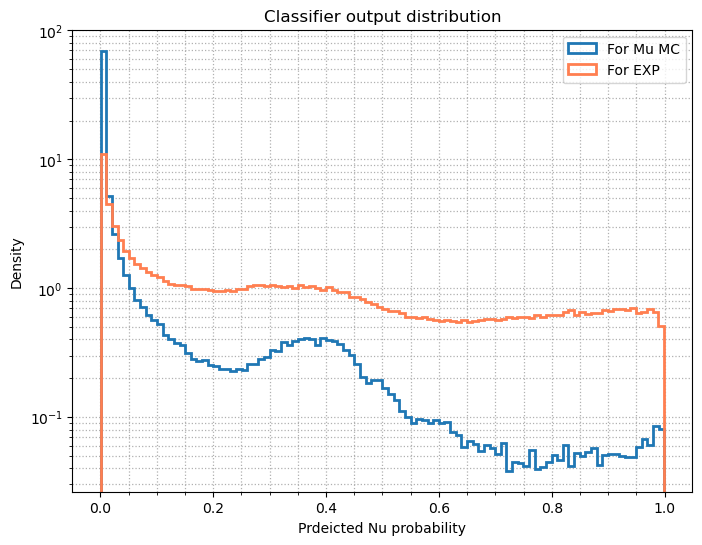

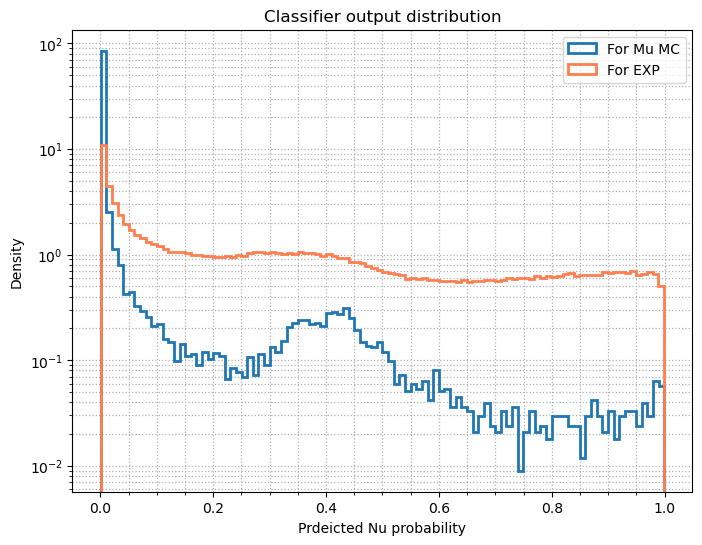

In [48]:
for h, s in [(0, 0), (5,2), (8,2), (16,2)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Mu MC')
    plt.hist(exp_probabilities, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label='For EXP')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.grid(which='both', ls=':', lw=0.9)

    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    plt.minorticks_on()
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/MC_EXP_p_distr_h{h}_s{s}.png")
    plt.show()
    plt.close()

KL(MC || EXP) = 0.267463
KL(EXP || MC) = 0.347116


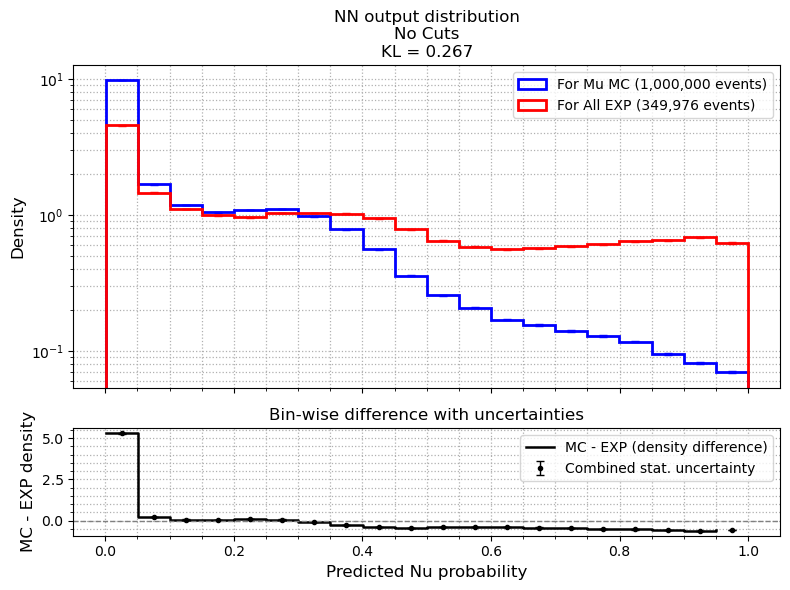

In [49]:
# Pmunu EXP VS MC
mc_mask = np.ones(len(probabilities), dtype=bool) #& (signal_hit_nums>=8) & (signal_string_nums>=2)
labels_masked, mc_probabilities_masked = labels[mc_mask], probabilities[mc_mask]
# mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
# labels_masked, probabilities_masked = labels[mask], probabilities[mask]


exp_mask = np.ones(len(exp_probabilities), dtype=bool)
exp_probas_masked = exp_probabilities[exp_mask]

BINS = 20

# ---------- 1) Common bin edges for both histograms ----------
# If these are probabilities, you may want (0, 1) instead
all_probs = np.concatenate([
    mc_probabilities_masked[~labels_masked],
    exp_probas_masked
])
bins = np.linspace(all_probs.min(), all_probs.max(), BINS + 1)

fig, axs = plt.subplots(2, figsize=(8, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

counts_mc, bins_mc, patches_mc = axs[0].hist(
    mc_probabilities_masked[~labels_masked],
    color='b',
    bins=bins,          # use the shared bins
    density=True,
    log=True,
    histtype='step',
    lw=2.,
    label=f'For Mu MC ({sum(mc_mask):,} events)'
)
bin_centers_mc = (bins_mc[:-1] + bins_mc[1:]) / 2
errors_mc = np.sqrt(counts_mc * sum(mc_mask) / BINS) * BINS / sum(mc_mask)
axs[0].errorbar(
    bin_centers_mc, counts_mc, yerr=errors_mc,
    fmt='none', color='b', capsize=3, capthick=1, elinewidth=1.
)

counts_exp, bins_exp, patches_exp = axs[0].hist(
    exp_probas_masked,
    color='red',
    bins=bins,         # use the same bins
    density=True,
    log=True,
    histtype='step',
    lw=2.,
    label=f'For All EXP ({sum(exp_mask):,} events)'
)
bin_centers_exp = (bins_exp[:-1] + bins_exp[1:]) / 2
errors_exp = np.sqrt(counts_exp * sum(exp_mask) / BINS) * BINS / sum(exp_mask)
axs[0].errorbar(
    bin_centers_exp, counts_exp, yerr=errors_exp,
    fmt='none', color='red', capsize=3, capthick=1, elinewidth=1.
)


axs[0].legend()
axs[0].grid(which='both', ls=':', lw=0.9)
#axs[0].set_xlabel("Predicted Nu probability", fontsize=12)
axs[0].set_ylabel("Density", fontsize=12)
axs[0].minorticks_on()

# ---------- 2) KL divergence between the two histograms ----------
# counts_* are densities because density=True.
# Convert to probability mass per bin: p_i ≈ density_i * bin_width_i.
bin_widths = np.diff(bins)

p = counts_mc * bin_widths
q = counts_exp * bin_widths

# Avoid zeros
eps = 1e-12
p = p + eps
q = q + eps

# Normalize to sum to 1 (probability distributions)
p /= p.sum()
q /= q.sum()

kl_mc_exp = np.sum(p * np.log(p / q))     # D_KL(MC || EXP)
kl_exp_mc = np.sum(q * np.log(q / p))     # D_KL(EXP || MC), optional

print(f"KL(MC || EXP) = {kl_mc_exp:.6g}")
print(f"KL(EXP || MC) = {kl_exp_mc:.6g}")
axs[0].set_title(f"NN output distribution\nNo Cuts\nKL = {kl_mc_exp:.3g}")

# ---------- 3) Second plot: bin-wise differences ----------
# ---------- 3) Second plot: step plot of bin-wise differences with error bars ----------

bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = np.diff(bins)

diff = counts_mc - counts_exp
error_diff = np.sqrt(errors_mc**2 + errors_exp**2)

# plt.figure(figsize=(8, 4))

# Step plot of differences
axs[1].step(bins[:-1], diff, where='post', color='k', linewidth=1.8, ls='-', label="MC - EXP (density difference)")

# Error bars at bin centers
axs[1].errorbar(
    bin_centers,
    diff,
    yerr=error_diff,
    fmt='o',
    color='k',
    markersize=3,
    capsize=3,
    elinewidth=1,
    label="Combined stat. uncertainty"
)

axs[1].axhline(0.0, linestyle='--', linewidth=1, color='gray')

axs[1].set_xlabel("Predicted Nu probability", fontsize=12)
axs[1].set_ylabel("MC - EXP density", fontsize=12)
axs[1].set_title(f"Bin-wise difference with uncertainties")
axs[1].grid(which='both', ls=':', lw=0.9)
axs[1].legend()
axs[1].minorticks_on()

plt.tight_layout()
plt.savefig(f"{fig_dir}/MC_EXP_p_distr_h0_s0_WITHDIFF.png")
plt.show()
plt.close()

# 5. Features: Sorce VS Target 

## 5.1 ReTrain DD (Domain Discriminator) only to predict domain labels

Creating model copies for domain discriminator training...
Base model copy frozen: 0 trainable parameters
New domain discriminator: 2,113 total parameters
Trainable parameters: 2,113

Preparing domain discrimination training data...
Data split prepared:
- Train samples: 160,000
- Validation samples: 40,000
- Total samples: 200,000
- Features shape: torch.Size([160000, 64])

Training setup:
- Optimizer: Adam (lr=0.001)
- Loss: BCEWithLogitsLoss
- Batch size: 512
- Epochs: 20

Training domain discriminator with FIXED encoder features...
Epoch  0: Train Loss=0.5600, Train Acc=0.7118, Val Loss=0.5117, Val Acc=0.7506
Epoch  5: Train Loss=0.4605, Train Acc=0.7777, Val Loss=0.4501, Val Acc=0.7847
Epoch 10: Train Loss=0.4384, Train Acc=0.7915, Val Loss=0.4309, Val Acc=0.7949
Epoch 15: Train Loss=0.4260, Train Acc=0.7988, Val Loss=0.4199, Val Acc=0.8021
Epoch 19: Train Loss=0.4192, Train Acc=0.8030, Val Loss=0.4135, Val Acc=0.8060

Training completed!
Final training accuracy: 0.8030
Final valid

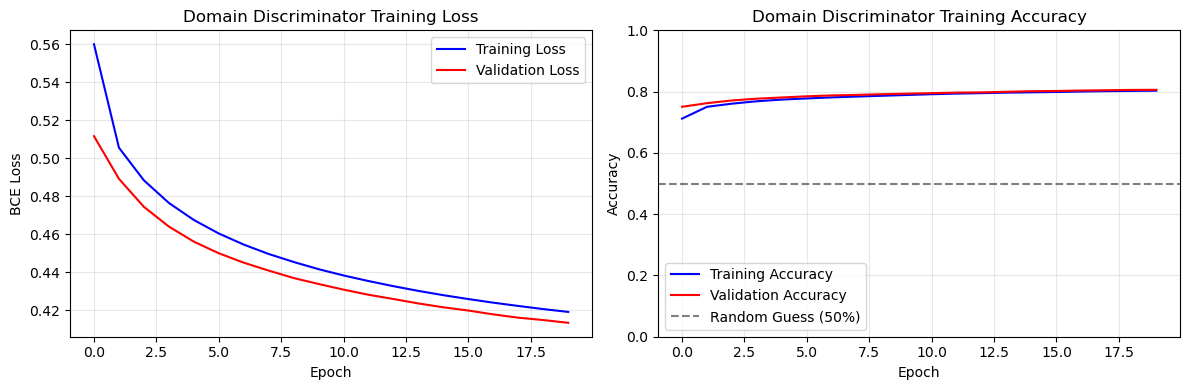

Training curves saved to: ../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr/report_BigMCSample_EqualAtmAtsro/figures//domain_discriminator_training_validation_curves.png


In [50]:
# Create distinct copies of models to avoid modifying originals
print("Creating model copies for domain discriminator training...")

# Create a copy of the base model and freeze it completely
model_copy = create_model(config['model'])
model_copy.load_state_dict(checkpoint['base_model_state_dict'])
model_copy.to(DEVICE)
model_copy.eval()

# Freeze ALL parameters of the base model copy
for param in model_copy.parameters():
    param.requires_grad = False

print(f"Base model copy frozen: {sum(p.requires_grad for p in model_copy.parameters())} trainable parameters")

# Create a new domain discriminator for training
dd_copy = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
dd_copy.to(DEVICE)

print(f"New domain discriminator: {sum(p.numel() for p in dd_copy.parameters()):,} total parameters")
print(f"Trainable parameters: {sum(p.numel() for p in dd_copy.parameters() if p.requires_grad):,}")

# Prepare data for domain discrimination training with train/val split
print("\nPreparing domain discrimination training data...")

# Use a balanced subset of source and target features
n_samples_per_domain = min(len(target_dataset), 100_000)  # Balance and limit for training

# Source features (muons only to balance with unlabeled target)
source_indices = np.where(~labels)[0][:n_samples_per_domain]
source_features_full = torch.tensor(features[source_indices], device=DEVICE)

# Target features 
target_indices = np.random.choice(len(target_dataset), n_samples_per_domain, replace=False)
target_features_full = target_features[target_indices].to(DEVICE)

# Combine features and create domain labels
all_features = torch.cat([source_features_full, target_features_full], dim=0)
all_domain_labels = torch.cat([
    torch.zeros(n_samples_per_domain),  # 0 = source
    torch.ones(n_samples_per_domain)    # 1 = target  
], dim=0).to(DEVICE)

# Shuffle the data
shuffle_idx = torch.randperm(len(all_features))
all_features = all_features[shuffle_idx]
all_domain_labels = all_domain_labels[shuffle_idx]

# Split into train/validation (80/20 split)
train_size = int(0.8 * len(all_features))
train_features = all_features[:train_size]
train_domain_labels = all_domain_labels[:train_size]
val_features = all_features[train_size:]
val_domain_labels = all_domain_labels[train_size:]

print(f"Data split prepared:")
print(f"- Train samples: {len(train_features):,}")
print(f"- Validation samples: {len(val_features):,}")
print(f"- Total samples: {len(all_features):,}")
print(f"- Features shape: {train_features.shape}")

# Setup training for domain discriminator
dd_optimizer = torch.optim.Adam(dd_copy.parameters(), lr=0.001)
dd_criterion = torch.nn.BCEWithLogitsLoss()
batch_size = 512
n_epochs = 20

print(f"\nTraining setup:")
print(f"- Optimizer: Adam (lr=0.001)")
print(f"- Loss: BCEWithLogitsLoss")
print(f"- Batch size: {batch_size}")
print(f"- Epochs: {n_epochs}")

# Function to evaluate on validation set
def evaluate_on_validation(model, features, labels, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    n_batches = 0
    
    with torch.no_grad():
        for i in range(0, len(features), batch_size):
            batch_features = features[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            
            domain_logits = model(batch_features)
            domain_loss = criterion(domain_logits.squeeze(), batch_labels)
            
            domain_probs = torch.sigmoid(domain_logits.squeeze())
            domain_preds = (domain_probs > 0.5).float()
            
            total_loss += domain_loss.item()
            total_correct += (domain_preds == batch_labels).float().sum().item()
            n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_accuracy = total_correct / len(features)
    return avg_loss, avg_accuracy

# Train domain discriminator with frozen feature extractor
print(f"\nTraining domain discriminator with FIXED encoder features...")

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(n_epochs):
    # Training phase
    dd_copy.train()
    epoch_loss = 0.0
    epoch_correct = 0
    n_batches = 0
    
    # Create training batches
    for i in range(0, len(train_features), batch_size):
        batch_features = train_features[i:i+batch_size]
        batch_labels = train_domain_labels[i:i+batch_size]
        
        dd_optimizer.zero_grad()
        
        # Forward pass through domain discriminator ONLY
        # Using pre-extracted features (frozen encoder)
        domain_logits = dd_copy(batch_features)
        domain_loss = dd_criterion(domain_logits.squeeze(), batch_labels)
        
        domain_loss.backward()
        dd_optimizer.step()
        
        # Track metrics
        domain_probs = torch.sigmoid(domain_logits.squeeze())
        domain_preds = (domain_probs > 0.5).float()
        
        epoch_loss += domain_loss.item()
        epoch_correct += (domain_preds == batch_labels).float().sum().item()
        n_batches += 1
    
    # Calculate training metrics
    train_loss = epoch_loss / n_batches
    train_accuracy = epoch_correct / len(train_features)
    
    # Validation phase
    val_loss, val_accuracy = evaluate_on_validation(dd_copy, val_features, val_domain_labels, dd_criterion)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:2d}: Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.4f}, " +
              f"Val Loss={val_loss:.4f}, Val Acc={val_accuracy:.4f}")

print("\nTraining completed!")
print(f"Final training accuracy: {train_accuracies[-1]:.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")
print(f"Note: High accuracy (>80%) indicates encoder features are NOT domain-independent")
print(f"Note: Low accuracy (~50%) indicates encoder features ARE domain-independent")

# Check for overfitting
train_val_gap = abs(train_accuracies[-1] - val_accuracies[-1])
if train_val_gap > 0.1:
    print(f"⚠️ WARNING: Possible overfitting detected! Train-Val gap: {train_val_gap:.4f}")
else:
    print(f"✅ No significant overfitting. Train-Val gap: {train_val_gap:.4f}")

# Plot training curves with validation
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.plot(val_losses, 'r-', label='Validation Loss')
plt.title('Domain Discriminator Training Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)  
plt.plot(train_accuracies, 'b-', label='Training Accuracy')
plt.plot(val_accuracies, 'r-', label='Validation Accuracy')
plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Random Guess (50%)')
plt.title('Domain Discriminator Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{fig_dir}/domain_discriminator_training_validation_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {fig_dir}/domain_discriminator_training_validation_curves.png")

In [51]:
# Final evaluation on the full test set to verify domain independence
print("=== Final Domain Independence Test ===")

# Test on the original full domain discrimination data (using existing variables)
dd_copy.eval()
with torch.no_grad():
    # Use existing all_domain_features and domain_labels from earlier in notebook
    test_domain_logits = dd_copy(all_domain_features.to(DEVICE))
    test_domain_probs = torch.sigmoid(test_domain_logits.squeeze()).cpu().numpy()
    test_domain_preds = (test_domain_probs > 0.5).astype(float)

# Calculate test metrics
test_accuracy = accuracy_score(domain_labels.numpy(), test_domain_preds)
test_auc = roc_auc_score(domain_labels.numpy(), test_domain_probs)

print(f"Domain Discriminator Test Results:")
print(f"- Test Accuracy:  {test_accuracy:.4f}")
print(f"- Test AUC:       {test_auc:.4f}")

print(f"\n=== Domain Independence Analysis ===")
if test_accuracy < 0.55 and abs(test_auc - 0.5) < 0.05:
    verdict = "✅ EXCELLENT domain independence"
elif test_accuracy < 0.60 and abs(test_auc - 0.5) < 0.10:
    verdict = "✅ GOOD domain independence"
elif test_accuracy < 0.70 and abs(test_auc - 0.5) < 0.20:
    verdict = "⚠️ MODERATE domain independence"
else:
    verdict = "❌ POOR domain independence"

print(f"Verdict: {verdict}")
print(f"Validation accuracy: {val_accuracies[-1]:.4f} (should be close to test accuracy)")
print(f"Overfitting check: Train-Val gap = {train_val_gap:.4f} (should be <0.1)")

# Compare with original DA model results
print(f"\n=== Comparison with Original DA Results ===")
print(f"Original DA Domain Accuracy: 0.4217")
print(f"Original DA Domain AUC:      0.5252") 
print(f"Retrained DD Test Accuracy:  {test_accuracy:.4f}")
print(f"Retrained DD Test AUC:       {test_auc:.4f}")

# Summary
if test_accuracy < 0.6:
    print(f"\n🎯 CONCLUSION: The encoder produces domain-independent features!")
    print(f"   Domain adaptation was successful - DD cannot distinguish domains reliably.")
else:
    print(f"\n⚠️ CONCLUSION: The encoder still contains some domain-specific information.")
    print(f"   Domain adaptation may need improvement.")
    
print(f"\nFinal trained DD saved in variables: dd_copy, val_accuracies, train_accuracies")

=== Final Domain Independence Test ===
Domain Discriminator Test Results:
- Test Accuracy:  0.8117
- Test AUC:       0.8880

=== Domain Independence Analysis ===
Verdict: ❌ POOR domain independence
Validation accuracy: 0.8060 (should be close to test accuracy)
Overfitting check: Train-Val gap = 0.0030 (should be <0.1)

=== Comparison with Original DA Results ===
Original DA Domain Accuracy: 0.4217
Original DA Domain AUC:      0.5252
Retrained DD Test Accuracy:  0.8117
Retrained DD Test AUC:       0.8880

⚠️ CONCLUSION: The encoder still contains some domain-specific information.
   Domain adaptation may need improvement.

Final trained DD saved in variables: dd_copy, val_accuracies, train_accuracies


## 5.2 UMAP Visualization of Source vs Target Features

In [52]:
# UMAP visualization of source vs target feature distributions
print("=== UMAP Analysis of Feature Space ===")

# Install umap if not available (uncomment if needed)
# !pip install umap-learn

import umap
from matplotlib.patches import Patch

# Prepare data for UMAP visualization
print("Preparing data for UMAP visualization...")

# Use a subset for visualization (UMAP can be slow on large datasets)
n_viz_samples = 10000  # Adjust based on computational resources
n_source_viz = min(n_viz_samples // 2, len(source_features_mu))
n_target_viz = min(n_viz_samples // 2, len(target_features))

# Sample source features (MC muons)
source_viz_indices = np.random.choice(len(source_features_mu), n_source_viz, replace=False)
source_viz_features = source_features_mu[source_viz_indices].cpu().numpy()

# Sample target features (Experimental data)  
target_viz_indices = np.random.choice(len(target_features), n_target_viz, replace=False)
target_viz_features = target_features[target_viz_indices].cpu().numpy()

# Combine for UMAP fitting
all_viz_features = np.concatenate([source_viz_features, target_viz_features], axis=0)
domain_viz_labels = np.concatenate([
    np.zeros(n_source_viz),  # 0 = source (MC)
    np.ones(n_target_viz)    # 1 = target (Exp)
], axis=0)

print(f"UMAP visualization data:")
print(f"- Source (MC) samples: {n_source_viz:,}")
print(f"- Target (Exp) samples: {n_target_viz:,}")
print(f"- Total samples: {len(all_viz_features):,}")
print(f"- Feature dimension: {all_viz_features.shape[1]}")

# Configure UMAP parameters
umap_params = {
    'n_neighbors': 15,      # Local neighborhood size
    'min_dist': 0.1,        # Minimum distance between points
    'n_components': 2,      # 2D embedding
    'metric': 'euclidean',  # Distance metric
    #'random_state': 42      # Reproducibility
}

print(f"\nUMAP parameters: {umap_params}")
print("Fitting UMAP (this may take a moment)...")

# Fit UMAP
reducer = umap.UMAP(**umap_params)
embedding = reducer.fit_transform(all_viz_features)

print("UMAP fitting completed!")

# Split embedding back to source and target
source_embedding = embedding[:n_source_viz]
target_embedding = embedding[n_source_viz:]

print(f"Embedding shape: {embedding.shape}")
print(f"Source embedding: {source_embedding.shape}")
print(f"Target embedding: {target_embedding.shape}")

=== UMAP Analysis of Feature Space ===
Preparing data for UMAP visualization...
UMAP visualization data:
- Source (MC) samples: 5,000
- Target (Exp) samples: 5,000
- Total samples: 10,000
- Feature dimension: 64

UMAP parameters: {'n_neighbors': 15, 'min_dist': 0.1, 'n_components': 2, 'metric': 'euclidean'}
Fitting UMAP (this may take a moment)...
UMAP fitting completed!
Embedding shape: (10000, 2)
Source embedding: (5000, 2)
Target embedding: (5000, 2)


KDE computation done. Plotting...


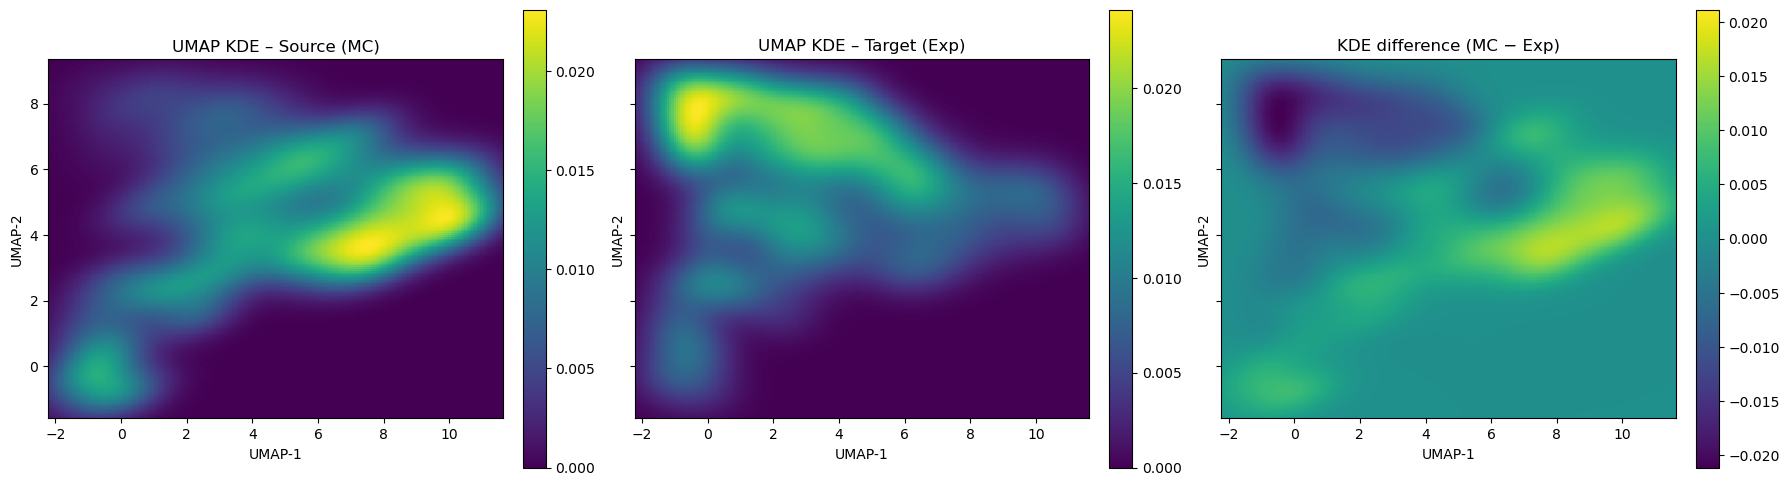

In [57]:
from scipy.stats import gaussian_kde

# ==========================
# # 2D KDE in UMAP space
# # ==========================

# print("Computing 2D KDEs in UMAP space...")

# # Stack coordinates as 2×N for gaussian_kde
# src_coords = source_embedding.T   # shape (2, n_source_viz)
# tgt_coords = target_embedding.T   # shape (2, n_target_viz)

# # Define a common grid over the UMAP plane
# x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
# y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()

# # Add a bit of padding
# pad_x = 0.05 * (x_max - x_min)
# pad_y = 0.05 * (y_max - y_min)
# x_min -= pad_x
# x_max += pad_x
# y_min -= pad_y
# y_max += pad_y

# # Grid resolution
# nx, ny = 200, 200
# xs = np.linspace(x_min, x_max, nx)
# ys = np.linspace(y_min, y_max, ny)
# xx, yy = np.meshgrid(xs, ys)
# grid_coords = np.vstack([xx.ravel(), yy.ravel()])  # shape (2, nx*ny)

# # # KDE for source (MC) and target (Exp)
# kde_source = gaussian_kde(src_coords)   # you can tune bw_method if needed
# kde_target = gaussian_kde(tgt_coords)

# src_density = kde_source(grid_coords).reshape(ny, nx)
# tgt_density = kde_target(grid_coords).reshape(ny, nx)

# # Difference (source - target)
# diff_density = src_density - tgt_density

print("KDE computation done. Plotting...")

# ==========================
# Plot KDEs and difference
# ==========================
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Source KDE
im0 = axs[0].imshow(
    src_density,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='equal',
    interpolation='none'
)
axs[0].set_title("UMAP KDE – Source (MC)")
axs[0].set_xlabel("UMAP-1")
axs[0].set_ylabel("UMAP-2")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Target KDE
im1 = axs[1].imshow(
    tgt_density,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='equal',
    interpolation='none'
)
axs[1].set_title("UMAP KDE – Target (Exp)")
axs[1].set_xlabel("UMAP-1")
axs[1].set_ylabel("UMAP-2")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# Difference KDE (Source - Target)
vmax = np.max(np.abs(diff_density))
im2 = axs[2].imshow(
    diff_density,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='equal',
    vmin=-vmax,
    vmax=vmax,
    interpolation='none'
)
axs[2].set_title("KDE difference (MC − Exp)")
axs[2].set_xlabel("UMAP-1")
axs[2].set_ylabel("UMAP-2")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{fig_dir}/umap_kde_mc_vs_exp.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [56]:
# ==========================
# Numerical scores from KDE
# ==========================

dx = xs[1] - xs[0]
dy = ys[1] - ys[0]
cell_area = dx * dy

# Normalize densities so they integrate to 1 over the grid
src_pdf = src_density / (src_density.sum() * cell_area)
tgt_pdf = tgt_density / (tgt_density.sum() * cell_area)

# 1) Integrated absolute difference (L1 distance)
l1_diff = np.sum(np.abs(src_pdf - tgt_pdf)) * cell_area

# 2) Optional: L2 distance
l2_diff = np.sqrt(np.sum((src_pdf - tgt_pdf) ** 2) * cell_area)

# 3) Optional: JS divergence on the grid (symmetric, bounded)
eps = 1e-12
p = src_pdf + eps
q = tgt_pdf + eps
p /= (p.sum() * cell_area)
q /= (q.sum() * cell_area)
m = 0.5 * (p + q)

js_div = 0.5 * np.sum(p * np.log(p / m) + q * np.log(q / m)) * cell_area

print(f"Integrated L1 difference (∫|p - q|): {l1_diff:.6g}")
print(f"L2 distance (sqrt(∫(p - q)^2)):     {l2_diff:.6g}")
print(f"JS divergence (UMAP KDE):           {js_div:.6g}")


Integrated L1 difference (∫|p - q|): 0.749164
L2 distance (sqrt(∫(p - q)^2)):     0.0845842
JS divergence (UMAP KDE):           0.104117


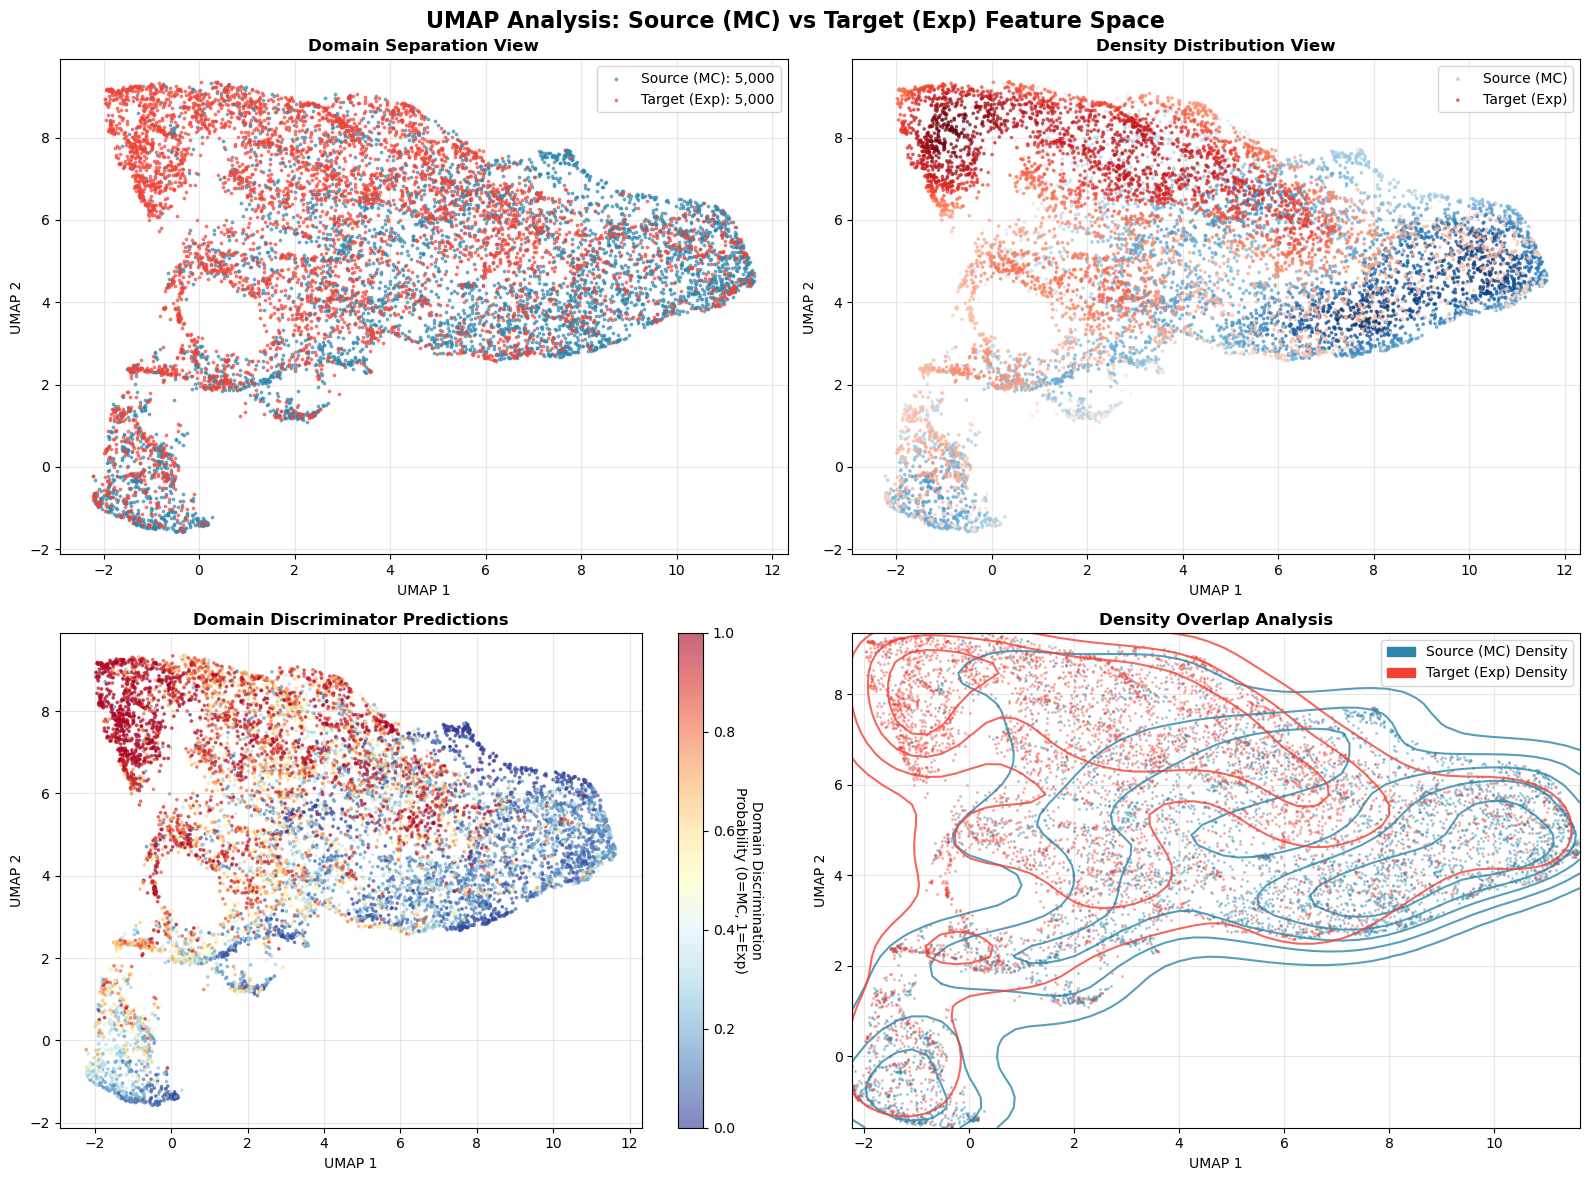


=== UMAP Feature Space Analysis ===
Feature space metrics:
- Source cluster center: (4.93, 4.30)
- Target cluster center: (2.71, 5.69)
- Center distance: 2.620
- Average spread: 3.913
- Overlap ratio: 0.670 (lower = more overlap)
- Overlap assessment: ✅ GOOD overlap - domains partially mixed

Domain discrimination on UMAP sample:
- Accuracy: 0.8060
- AUC: 0.8915

UMAP analysis completed! Visualization saved to:
../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr/report_BigMCSample_EqualAtmAtsro/figures//umap_feature_analysis.png


In [54]:
# Create comprehensive UMAP visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UMAP Analysis: Source (MC) vs Target (Exp) Feature Space', fontsize=16, fontweight='bold')

# Colors and styling
source_color = '#2E86AB'  # Blue for MC
target_color = '#F24236'  # Red for Exp
alpha = 0.6
point_size = 3

# Plot 1: Basic domain separation
ax1 = axes[0, 0]
scatter1 = ax1.scatter(source_embedding[:, 0], source_embedding[:, 1], 
                      c=source_color, alpha=alpha, s=point_size, label=f'Source (MC): {n_source_viz:,}')
scatter2 = ax1.scatter(target_embedding[:, 0], target_embedding[:, 1], 
                      c=target_color, alpha=alpha, s=point_size, label=f'Target (Exp): {n_target_viz:,}')
ax1.set_title('Domain Separation View', fontweight='bold')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Density-based visualization
ax2 = axes[0, 1]
# Create density plots
from scipy.stats import gaussian_kde

# Calculate point density for color mapping
source_xy = source_embedding.T
target_xy = target_embedding.T

# Source density
if len(source_xy[0]) > 1:
    source_density = gaussian_kde(source_xy)(source_xy)
    source_density = source_density / source_density.max()
else:
    source_density = np.ones(len(source_xy[0]))

# Target density  
if len(target_xy[0]) > 1:
    target_density = gaussian_kde(target_xy)(target_xy)
    target_density = target_density / target_density.max()
else:
    target_density = np.ones(len(target_xy[0]))

scatter3 = ax2.scatter(source_embedding[:, 0], source_embedding[:, 1], 
                      c=source_density, cmap='Blues', s=point_size, alpha=alpha, label='Source (MC)')
scatter4 = ax2.scatter(target_embedding[:, 0], target_embedding[:, 1], 
                      c=target_density, cmap='Reds', s=point_size, alpha=alpha, label='Target (Exp)')
ax2.set_title('Density Distribution View', fontweight='bold')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Domain discrimination predictions overlay
ax3 = axes[1, 0]
# Get domain predictions for visualization samples
viz_features_tensor = torch.tensor(all_viz_features, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    dd_copy.eval()
    viz_domain_logits = dd_copy(viz_features_tensor)
    viz_domain_probs = torch.sigmoid(viz_domain_logits.squeeze()).cpu().numpy()

# Color by domain discrimination confidence
scatter5 = ax3.scatter(embedding[:, 0], embedding[:, 1], 
                      c=viz_domain_probs, cmap='RdYlBu_r', s=point_size, 
                      alpha=alpha, vmin=0, vmax=1)
cbar = plt.colorbar(scatter5, ax=ax3)
cbar.set_label('Domain Discrimination\nProbability (0=MC, 1=Exp)', rotation=270, labelpad=20)
ax3.set_title('Domain Discriminator Predictions', fontweight='bold')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)

# Plot 4: Overlap analysis
ax4 = axes[1, 1]
# Create contour plots to show overlap
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

# Kernel density estimation for contours
if len(source_embedding) > 10:
    source_kde = gaussian_kde(source_embedding.T)
    target_kde = gaussian_kde(target_embedding.T)
    
    # Create grid for contour plots
    x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
    y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    source_density_grid = source_kde(positions).reshape(xx.shape)
    target_density_grid = target_kde(positions).reshape(xx.shape)
    
    # Plot contours
    source_contour = ax4.contour(xx, yy, source_density_grid, colors=[source_color], alpha=0.8, levels=5)
    target_contour = ax4.contour(xx, yy, target_density_grid, colors=[target_color], alpha=0.8, levels=5)
    
    # Add scatter points
    ax4.scatter(source_embedding[:, 0], source_embedding[:, 1], 
               c=source_color, alpha=0.3, s=point_size/2, label='Source (MC)')
    ax4.scatter(target_embedding[:, 0], target_embedding[:, 1], 
               c=target_color, alpha=0.3, s=point_size/2, label='Target (Exp)')
    
    # Create legend with patches
    source_patch = mpatches.Patch(color=source_color, label='Source (MC) Density')
    target_patch = mpatches.Patch(color=target_color, label='Target (Exp) Density')
    ax4.legend(handles=[source_patch, target_patch])
else:
    # Fallback if too few points
    ax4.scatter(source_embedding[:, 0], source_embedding[:, 1], 
               c=source_color, alpha=alpha, s=point_size, label='Source (MC)')
    ax4.scatter(target_embedding[:, 0], target_embedding[:, 1], 
               c=target_color, alpha=alpha, s=point_size, label='Target (Exp)')
    ax4.legend()

ax4.set_title('Density Overlap Analysis', fontweight='bold')
ax4.set_xlabel('UMAP 1')
ax4.set_ylabel('UMAP 2')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/umap_feature_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate overlap metrics
print("\n=== UMAP Feature Space Analysis ===")

# Calculate center distances
source_center = np.mean(source_embedding, axis=0)
target_center = np.mean(target_embedding, axis=0)
center_distance = np.linalg.norm(source_center - target_center)

# Calculate spread (average distance from center)
source_spread = np.mean(np.linalg.norm(source_embedding - source_center, axis=1))
target_spread = np.mean(np.linalg.norm(target_embedding - target_center, axis=1))
avg_spread = (source_spread + target_spread) / 2

# Overlap ratio
overlap_ratio = center_distance / avg_spread

print(f"Feature space metrics:")
print(f"- Source cluster center: ({source_center[0]:.2f}, {source_center[1]:.2f})")
print(f"- Target cluster center: ({target_center[0]:.2f}, {target_center[1]:.2f})")
print(f"- Center distance: {center_distance:.3f}")
print(f"- Average spread: {avg_spread:.3f}")
print(f"- Overlap ratio: {overlap_ratio:.3f} (lower = more overlap)")

# Interpretation
if overlap_ratio < 0.5:
    overlap_verdict = "✅ EXCELLENT overlap - domains are well mixed"
elif overlap_ratio < 1.0:
    overlap_verdict = "✅ GOOD overlap - domains partially mixed"  
elif overlap_ratio < 2.0:
    overlap_verdict = "⚠️ MODERATE overlap - some domain separation"
else:
    overlap_verdict = "❌ POOR overlap - domains clearly separated"

print(f"- Overlap assessment: {overlap_verdict}")

# Domain discrimination correlation
dd_accuracy_on_viz = accuracy_score(domain_viz_labels, (viz_domain_probs > 0.5).astype(int))
dd_auc_on_viz = roc_auc_score(domain_viz_labels, viz_domain_probs)
print(f"\nDomain discrimination on UMAP sample:")
print(f"- Accuracy: {dd_accuracy_on_viz:.4f}")
print(f"- AUC: {dd_auc_on_viz:.4f}")

print(f"\nUMAP analysis completed! Visualization saved to:")
print(f"{fig_dir}/umap_feature_analysis.png")